In [69]:
from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END


In [70]:
class ReviewOutput(BaseModel):
    review_report: str = Field("This is the review report that you'll be generating.")

In [71]:
class CodeReviewAgentState(TypedDict):
    code: Annotated[str, "The code that will be reviewed by LLM."]
    logic_review: Annotated[str, "Stores the logical review for the code"]
    style_review: Annotated[str, "Stores the stylistic review for the code"]
    suggestion: Annotated[str, "Stores the improvements for the code, based on the locial_review and style_review."]
    final_report: Annotated[str, "Compilation of suggestions and issues."]

In [72]:
def logical_check(state):
    node_prompt = ChatPromptTemplate.from_messages(
        [
            ('system','You are a senior software engineer, whose goal is to review the code shared with you.'),
            ('user', """Go through this \n \n
            {code} \n \n   
            and check if it is logically correct. If it is, then you should state why it is correct.
            If it is not correct logically then you should point out the issues.""")
        ]
    )

    node_chain = node_prompt | llm
    review = node_chain.invoke(
        {
            "code": state['code']
        }
    ).content

    return {'logic_review': review}

In [73]:
def style_check(state):
    node_prompt = ChatPromptTemplate.from_messages(
        [
            ('system','You are a senior software engineer, whose goal is to review the code shared with you. Your main goal here is to check proper naming convention of variables, methods, classes etc. PEP8 Compliance, if docstrings and comments are used properly, if code structure is correct(eg:  functions doing too many things, deeply nested logic, magic numbers without explanation)'),
            ('user', """Go through this \n \n
            {code} \n \n   
            and check if it is stylistically correct. If it is, then you should state why it is correct.
            If it is not correct stylistically then you should point out the issues.""")
        ]
    )

    node_chain = node_prompt | llm
    review = node_chain.invoke(
        {
            "code": state['code']
        }
    ).content

    return {'style_review': review}

In [74]:
def suggestion(state):
    node_prompt = ChatPromptTemplate.from_messages(
        [
            ('system','You are a senior software engineer, given the code and the logical issues and stylistic issues for the code, give me suggestions and improvements based on the issues shared with you. No need to go through the code just refer it and go through the issues shared with you. Return the result in the form of a report.'),
            ('user', """Go through this \n \n
            {code} \n \n
            these issues: 
            logical issues: {logic_review}
            \n
            style issues: {style_review}
            and give me suggestions and improvements.
            Based on the issues if you think no improvements or suggestions are required then return response accordingly.
            But if you think suggestions and improvements are requried then create a summary report accordingly""")
        ]
    )

    node_chain = node_prompt | llm
    suggestion = node_chain.invoke(
        {
            "code": state['code'],
            "logic_review": state['logic_review'],
            "style_review": state['style_review']
        }
    ).content

    return {'suggestion': suggestion}



In [75]:
def write_report(state):
    node_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', """
             You are a senior software engineer writing a code review.
    
    Based on the following findings, write a structured review report With the following structure.
    
    Logic Issues:
    
    Style Issues:
    
    Suggestions:
    
    Format the report EXACTLY like this:
    
    ## Code Review Report
    
    ### Logic Issues
    - <issue 1>
    - <issue 2>
    
    ### Style Issues
    - <issue 1>
    - <issue 2>
    
    ### Suggestions
    - <suggestion 1>
    - <suggestion 2>
    
    ### Summary
    <2-3 sentence overall summary>
    
    Use markdown formatting. Each point on its own line. No squishing.
            """),
            ('user', 'logical issues: {logic_issues}, style issues: {style_issues}, suggestions: {suggestions}')
        ]
    )

    node_chain = node_prompt | report_llm
    report = node_chain.invoke(
        {
            "suggestions": state['suggestion'],
            "logic_issues": state['logic_review'],
            "style_issues": state['style_review']
        }
    ).review_report

    return {'final_report': report}

In [76]:
llm = ChatOpenAI(model='gpt-5', temperature=0)
report_llm = llm.with_structured_output(ReviewOutput)

In [77]:
code_review_agent = StateGraph(CodeReviewAgentState)
code_review_agent.add_node('logical_check', logical_check)
code_review_agent.add_node('style_check', style_check)
code_review_agent.add_node('suggestion', suggestion)
code_review_agent.add_node('write_report', write_report)

code_review_agent.add_edge(START, 'logical_check')
code_review_agent.add_edge('logical_check', 'style_check')
code_review_agent.add_edge('style_check', 'suggestion')
code_review_agent.add_edge('suggestion', 'write_report')
code_review_agent.add_edge('write_report', END)



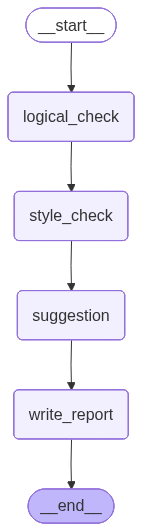

In [78]:
code_review_agent_compiled = code_review_agent.compile()
code_review_agent_compiled

In [80]:
result = code_review_agent_compiled.invoke(
    {
        'code': """
        def calc(l, x):
            t = 0
            c = 0
            for i in range(len(l)):
                if l[i] != x:
                    t = t + l[i]
                    c = c + 1
            avg = t/c
            return avg

        def process(data):
            result = []
            for i in range(len(data)):
                val = calc(data[i], None)
                result.append(val)
            return result
        """
    }
)

print(result['final_report'])

## Code Review Report

### Logic Issues
- Division by zero when the input list is empty or all elements equal the sentinel (c == 0 leads to ZeroDivisionError).
- Fragile None comparison semantics: using != None is non-idiomatic and can behave unexpectedly; prefer is not None when excluding None.
- Assumes all included elements are numeric; non-numeric values will raise TypeError during accumulation.
- API inconsistency: process hardcodes exclude=None while calc accepts x, leading to misleading parameters and potential misuse.

### Style Issues
- Vague function names (calc, process); use descriptive names like average_excluding and compute_averages.
- Non-descriptive single-letter variables (l, t, c, i) and val; PEP 8 advises against l, O, I and favors clear names.
- Missing docstrings and type hints for both functions.
- Inconsistent PEP 8 spacing and operators; prefer spaces around operators and augmented assignment (+=).
- Avoid range(len(...)); iterate directly over sequence items (